In [1]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện huấn luyện Machine Learning
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

!pip install pandas numpy scikit-learn matplotlib seaborn joblib openpyxl scipy


Mounted at /content/drive


In [17]:
# Bước 2: Khai báo Đường dẫn, Nạp Dữ liệu & Chuẩn bị Ma trận X (31 Features) và y (Actual_Count)
import os
import sys
import json
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

# Cài đặt giao diện đồ thị khoa học chuẩn mực
sns.set_theme(style="whitegrid", font_scale=1.02)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# ĐƯỜNG DẪN DỰ ÁN
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"
DATA_CSV_PATH = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")
DATA_EXCEL_PATH = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.xlsx")

OUTPUT_MODEL_DIR = os.path.join(BASE_PATH, "LINEAR_REGRESSION_MODEL/models")
OUTPUT_RESULT_DIR = os.path.join(BASE_PATH, "LINEAR_REGRESSION_MODEL/results")
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_RESULT_DIR, exist_ok=True)

if os.path.exists(DATA_CSV_PATH):
    df_raw = pd.read_csv(DATA_CSV_PATH)
elif os.path.exists(DATA_EXCEL_PATH):
    df_raw = pd.read_excel(DATA_EXCEL_PATH)
else:
    df_raw = pd.read_csv("DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")

# Lọc lấy các mẫu hợp lệ đã trích xuất AI (Image_Status == 'FOUND')
df = df_raw[df_raw['Image_Status'] == 'FOUND'].copy()

# Danh sách toàn bộ 31 thuộc tính gốc
ALL_31_FEATURES = [
    # Nhóm 1: Vật chứa & Thể tích khối lúa (8 biến)
    'Bulk_Rice_Volume_mm3', 'Rice_Height_mm', 'Weight_g', 'Empty_Height_mm',
    'Pixels_Per_mm', 'Container_Detected_Diam_px', 'Inner_Diameter_mm', 'Container_Height_mm',
    # Nhóm 2: Bề mặt & Ước lượng (3 biến)
    'Whole_Grains_Count', 'Uniformity_Rate_Pct', 'Estimated_Total_Seeds_Hybrid',
    # Nhóm 3: Chiều dài hạt 2a (4 biến)
    'Grain_Length_mm_Mean', 'Grain_Length_mm_Min', 'Grain_Length_mm_Max', 'Grain_Length_mm_Std',
    # Nhóm 4: Chiều rộng hạt 2b (4 biến)
    'Grain_Width_mm_Mean', 'Grain_Width_mm_Min', 'Grain_Width_mm_Max', 'Grain_Width_mm_Std',
    # Nhóm 5: Chiều dày hạt 2c (4 biến)
    'Grain_Thickness_mm_Mean', 'Grain_Thickness_mm_Min', 'Grain_Thickness_mm_Max', 'Grain_Thickness_mm_Std',
    # Nhóm 6: Diện tích 2D (4 biến)
    'Grain_Area_mm2_Mean', 'Grain_Area_mm2_Min', 'Grain_Area_mm2_Max', 'Grain_Area_mm2_Std',
    # Nhóm 7: Thể tích 3D Hạt (4 biến)
    'Grain_Volume_mm3_Mean', 'Grain_Volume_mm3_Min', 'Grain_Volume_mm3_Max', 'Grain_Volume_mm3_Std'
]

TARGET_COL = 'Actual_Count'

# Chuyển đổi kiểu số
for col in ALL_31_FEATURES + [TARGET_COL]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=ALL_31_FEATURES + [TARGET_COL])

X = df_clean[ALL_31_FEATURES].values
y = df_clean[TARGET_COL].values
sample_ids = df_clean['Sample_ID'].values

print("=" * 95)
print("📊 TỔNG QUAN TẬP DỮ LIỆU ĐƯA VÀO HUẤN LUYỆN:")
print("=" * 95)
print(f"🔹 Tổng số mẫu hợp lệ : {len(df_clean)} mẫu")
print(f"🔹 Số chiều đặc trưng : {X.shape[1]} thuộc tính gốc")
print(f"🔹 Biến mục tiêu (Y)  : '{TARGET_COL}' (Số hạt lúa thực tế)")
print(f"🔹 Dải giá trị Y      : Từ {y.min():.0f} đến {y.max():.0f} hạt (Mean={y.mean():.1f}, Median={np.median(y):.1f})")
print("=" * 95)


📊 TỔNG QUAN TẬP DỮ LIỆU ĐƯA VÀO HUẤN LUYỆN:
🔹 Tổng số mẫu hợp lệ : 254 mẫu
🔹 Số chiều đặc trưng : 31 thuộc tính gốc
🔹 Biến mục tiêu (Y)  : 'Actual_Count' (Số hạt lúa thực tế)
🔹 Dải giá trị Y      : Từ 25 đến 305 hạt (Mean=163.1, Median=157.5)


In [18]:
# Bước 3: Phân Chia Tập Train (80%) / Test (20%) & Chuẩn Hóa StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test, sids_train, sids_test = train_test_split(
    X, y, sample_ids, test_size=0.20, random_state=42, shuffle=True
)

# Chuẩn hóa Z-Score trên tập Train (fit) và biến đổi cho cả Train và Test (transform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lưu scaler model
scaler_joblib_path = os.path.join(OUTPUT_MODEL_DIR, "scaler.joblib")
joblib.dump(scaler, scaler_joblib_path)

# Lưu tham số scaler dạng JSON
scaler_json_path = os.path.join(OUTPUT_MODEL_DIR, "scaler_params.json")
with open(scaler_json_path, "w", encoding="utf-8") as f:
    json.dump({
        "features": ALL_31_FEATURES,
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist()
    }, f, ensure_ascii=False, indent=2)

print("=" * 95)
print(f"🔹 Tập Huấn Luyện (Train Set): {len(X_train)} mẫu (80.0%)")
print(f"🔹 Tập Kiểm Thử  (Test Set) : {len(X_test)} mẫu (20.0%)")
print(f"💾 Đã lưu StandardScaler vào : {scaler_joblib_path}")
print("=" * 95)


🔹 Tập Huấn Luyện (Train Set): 203 mẫu (80.0%)
🔹 Tập Kiểm Thử  (Test Set) : 51 mẫu (20.0%)
💾 Đã lưu StandardScaler vào : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/models/scaler.joblib


In [19]:
# Bước 4: HUẤN LUYỆN & SO SÁNH CHÉO 6 BIẾN THỂ DỰA TRÊN CÂY QUYẾT ĐỊNH (5-FOLD CROSS VALIDATION)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, AdaBoostRegressor,
    HistGradientBoostingRegressor
)
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import os

# Định nghĩa 6 mô hình dựa trên Cây quyết định (Tree-based & Ensemble) ứng viên
models_dict = {
    "1. Decision Tree (Cây quyết định gốc)": DecisionTreeRegressor(random_state=42),
    "2. Random Forest (Bagging)": RandomForestRegressor(n_estimators=100, random_state=42),
    "3. Extra Trees (Cực kỳ ngẫu nhiên)": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "4. Gradient Boosting (Boosting)": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "5. AdaBoost (Adaptive Boosting)": AdaBoostRegressor(n_estimators=50, random_state=42),
    "6. HistGradientBoosting (Tối ưu lớn)": HistGradientBoostingRegressor(random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
leaderboard_records = []
fitted_models = {}
model_test_preds = {}

N_features = X_train.shape[1]

for model_name, model in models_dict.items():
    # 1. 5-Fold Cross Validation trên tập Train
    cv_r2 = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2')

    # 2. Huấn luyện trên toàn bộ tập Train
    model.fit(X_train_scaled, y_train)
    fitted_models[model_name] = model

    # 3. Dự đoán trên tập Train và Test
    y_tr_pred = model.predict(X_train_scaled)
    y_te_pred = model.predict(X_test_scaled)
    model_test_preds[model_name] = y_te_pred

    # 4. Tính toán các chỉ số đánh giá
    r2_tr = r2_score(y_train, y_tr_pred)
    r2_te = r2_score(y_test, y_te_pred)

    n_te = len(y_test)
    adj_r2_te = 1.0 - ((1.0 - r2_te) * (n_te - 1) / (n_te - N_features - 1)) if (n_te - N_features - 1) > 0 else r2_te

    # Tính thêm MSE ở đây
    mse_te = mean_squared_error(y_test, y_te_pred)
    mae_te = mean_absolute_error(y_test, y_te_pred)
    rmse_te = np.sqrt(mse_te) # Dùng luôn mse_te để tính căn bậc 2 cho nhanh
    mape_te = np.mean(np.abs((y_test - y_te_pred) / y_test)) * 100
    max_err_te = np.max(np.abs(y_test - y_te_pred))

    # Cập nhật dictionary
    leaderboard_records.append({
        'Mô_Hình_Hồi_Quy': model_name,
        'R2_Train': round(r2_tr, 4),
        'R2_CV_5Fold': round(np.mean(cv_r2), 4),
        'R2_Test': round(r2_te, 4),
        'Adj_R2_Test': round(adj_r2_te, 4),
        'MSE_Test (hạt^2)': round(mse_te, 2),
        'MAE_Test (hạt)': round(mae_te, 2),
        'RMSE_Test (hạt)': round(rmse_te, 2),
        'MAPE_Test (%)': round(mape_te, 2),
        'Max_Error (hạt)': round(max_err_te, 2)
    })

df_leaderboard = pd.DataFrame(leaderboard_records).sort_values(by='R2_Test', ascending=False).reset_index(drop=True)
df_leaderboard.index = df_leaderboard.index + 1

print("=" * 125)
print("🏆 BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG 6 THUẬT TOÁN CÂY QUYẾT ĐỊNH VÀ ENSEMBLE (CÓ THÊM MSE):")
print("=" * 125)
display(df_leaderboard)

# Xuất bảng so sánh ra CSV
report_csv_path = os.path.join(OUTPUT_RESULT_DIR, "tree_models_evaluation_report.csv")
df_leaderboard.to_csv(report_csv_path, index=False, encoding="utf-8-sig")
print(f"💾 Đã lưu bảng so sánh mô hình vào: {report_csv_path}")

🏆 BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG 6 THUẬT TOÁN CÂY QUYẾT ĐỊNH VÀ ENSEMBLE (CÓ THÊM MSE):


,Mô_Hình_Hồi_Quy,R2_Train,R2_CV_5Fold,R2_Test,Adj_R2_Test,MSE_Test (hạt^2),MAE_Test (hạt),RMSE_Test (hạt),MAPE_Test (%),Max_Error (hạt)
1,3. Extra Trees (Cực kỳ ngẫu nhiên),1.0000,0.9998,0.9999,0.9996,1.02,0.45,1.01,0.34,4.65
2,4. Gradient Boosting (Boosting),1.0000,0.9998,0.9998,0.9995,1.17,0.58,1.08,0.58,3.97
3,1. Decision Tree (Cây quyết định gốc),1.0000,0.9985,0.9997,0.9992,1.96,0.39,1.40,0.34,5.00
4,2. Random Forest (Bagging),0.9999,0.9994,0.9994,0.9985,3.89,1.40,1.97,1.15,6.60
5,6. HistGradientBoosting (Tối ưu lớn),0.9998,0.9969,0.9986,0.9962,9.84,2.10,3.14,1.74,9.54
6,5. AdaBoost (Adaptive Boosting),0.9972,0.9955,0.9973,0.9929,18.29,3.40,4.28,2.54,10.75


💾 Đã lưu bảng so sánh mô hình vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/tree_models_evaluation_report.csv


In [24]:
# Bước 5: CHỌN MÔ HÌNH TỐI ƯU NHẤT & TRÍCH XUẤT ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG (FEATURE IMPORTANCE)
import json
import joblib
import os
import pandas as pd

best_model_name = df_leaderboard.iloc[0]['Mô_Hình_Hồi_Quy']
best_model = fitted_models[best_model_name]

# Tạo từ điển lưu cấu hình và thông tin mô hình
model_info_dict = {
    "model_name": best_model_name,
    "target_variable": TARGET_COL, # Đảm bảo biến TARGET_COL đã được định nghĩa trước đó
    "number_of_features": len(ALL_31_FEATURES), # Đảm bảo danh sách biến ALL_31_FEATURES đã có
    "r2_score_test": float(df_leaderboard.iloc[0]['R2_Test']),
    "mse_test": float(df_leaderboard.iloc[0]['MSE_Test (hạt^2)']),
    "mae_test": float(df_leaderboard.iloc[0]['MAE_Test (hạt)']),
    "mape_test": float(df_leaderboard.iloc[0]['MAPE_Test (%)']),
    "feature_importances": []
}

print("=" * 100)
print(f"🌟 MÔ HÌNH TỐT NHẤT ĐƯỢC CHỌN: {best_model_name}")
print("=" * 100)

# CẢNH BÁO: HistGradientBoostingRegressor không có thuộc tính feature_importances_ mặc định
# Do đó, cần dùng hasattr() để kiểm tra xem mô hình có hỗ trợ trích xuất độ quan trọng hay không.
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_

    # Ghép tên biến và độ quan trọng, sau đó sắp xếp giảm dần
    feat_imp_df = pd.DataFrame({
        'Feature': ALL_31_FEATURES,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print(f"📊 MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (TOP FEATURE IMPORTANCES):")
    print("(Biến nào có % càng cao thì biến đó phân loại số hạt càng tốt)")

    for idx, row in feat_imp_df.iterrows():
        feat = row['Feature']
        imp = row['Importance']

        # Lưu vào file JSON
        model_info_dict["feature_importances"].append({
            "name": feat,
            "importance_score": float(imp),
            "importance_percentage": float(imp * 100)
        })

        # Chỉ in ra những biến có đóng góp > 0% để gọn console
        if imp > 0:
            print(f"   🔹 {feat:<30}: {imp * 100:>6.2f} %")
else:
    print(f"⚠️ Mô hình '{best_model_name}' (ví dụ: HistGradientBoosting) không lưu trữ feature_importances_ trực tiếp.")
    model_info_dict["note"] = "Model does not support direct feature_importances_ attribute."

print("=" * 100 + "\n")

# Lưu file mô hình (.joblib)
best_joblib_path = os.path.join(OUTPUT_MODEL_DIR, "best_tree_ensemble_model.joblib")
joblib.dump(best_model, best_joblib_path)

# Lưu thông tin mô hình (.json)
info_json_path = os.path.join(OUTPUT_MODEL_DIR, "best_tree_model_info.json")
with open(info_json_path, "w", encoding="utf-8") as f:
    json.dump(model_info_dict, f, ensure_ascii=False, indent=2)

print(f"💾 Đã lưu Cấu trúc Mô hình vào     : {best_joblib_path}")
print(f"💾 Đã lưu Thông tin/Chỉ số JSON vào: {info_json_path}")

🌟 MÔ HÌNH TỐT NHẤT ĐƯỢC CHỌN: 3. Extra Trees (Cực kỳ ngẫu nhiên)
📊 MỨC ĐỘ QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG (TOP FEATURE IMPORTANCES):
(Biến nào có % càng cao thì biến đó phân loại số hạt càng tốt)
   🔹 Container_Height_mm           :  31.95 %
   🔹 Inner_Diameter_mm             :  28.00 %
   🔹 Weight_g                      :  15.94 %
   🔹 Bulk_Rice_Volume_mm3          :  14.15 %
   🔹 Rice_Height_mm                :   5.51 %
   🔹 Empty_Height_mm               :   4.37 %
   🔹 Container_Detected_Diam_px    :   0.03 %
   🔹 Pixels_Per_mm                 :   0.03 %
   🔹 Estimated_Total_Seeds_Hybrid  :   0.00 %
   🔹 Whole_Grains_Count            :   0.00 %
   🔹 Grain_Width_mm_Std            :   0.00 %
   🔹 Grain_Volume_mm3_Min          :   0.00 %
   🔹 Grain_Length_mm_Std           :   0.00 %
   🔹 Grain_Area_mm2_Min            :   0.00 %
   🔹 Grain_Volume_mm3_Max          :   0.00 %
   🔹 Grain_Length_mm_Max           :   0.00 %
   🔹 Grain_Length_mm_Mean          :   0.00 %
   🔹 Grain_Thickness_mm_M

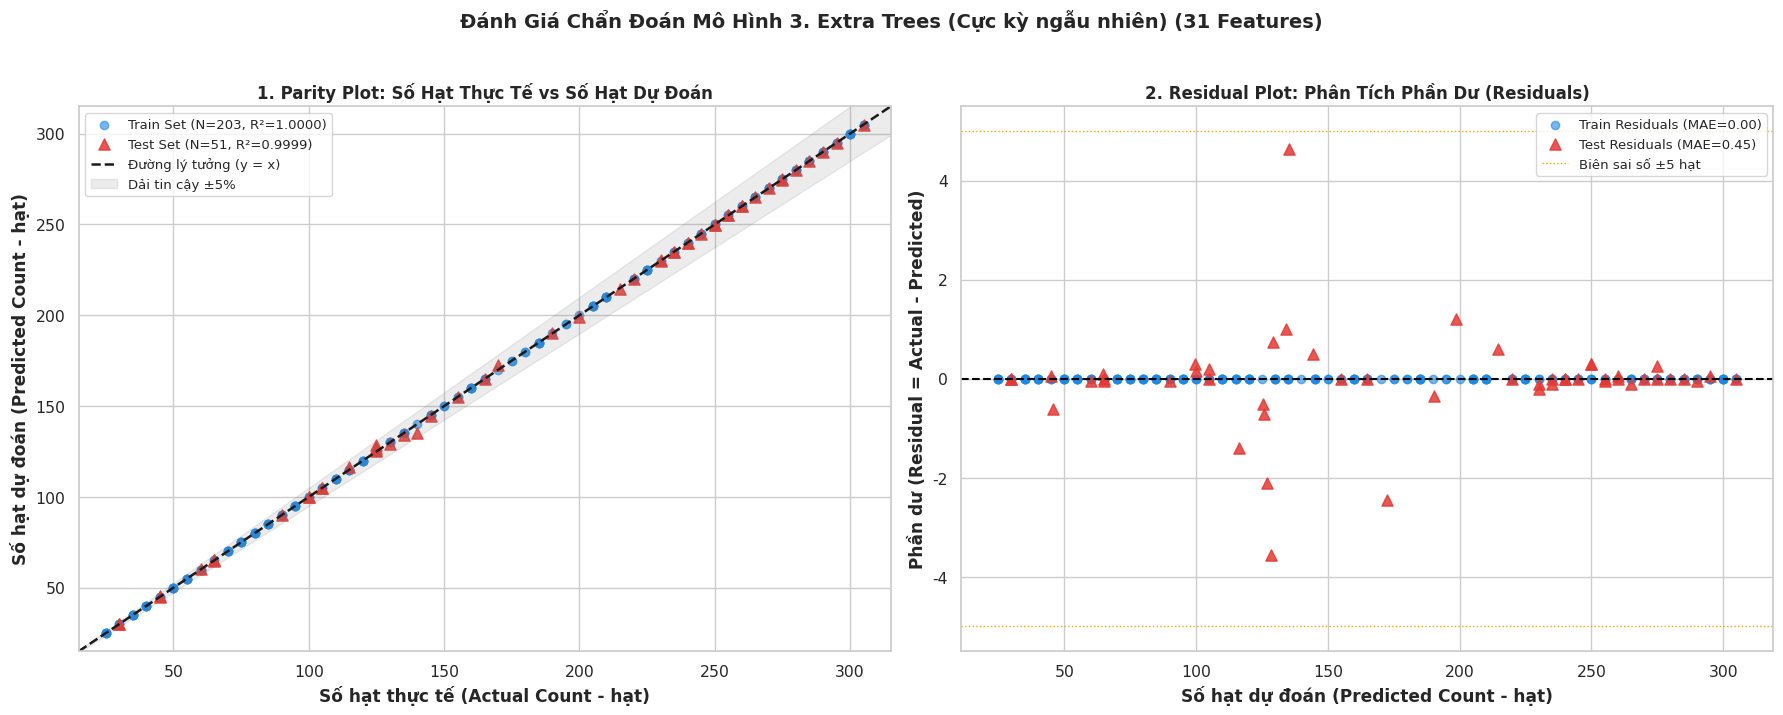

💾 Đã lưu biểu đồ Parity & Residual vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/1_model_diagnostic_parity_residual_plots.png


In [25]:
# Bước 6: TRỰC QUAN HÓA ĐÁNH GIÁ MÔ HÌNH (PARITY PLOT & RESIDUALS ANALYSIS)
y_tr_pred = best_model.predict(X_train_scaled)
y_te_pred = best_model.predict(X_test_scaled)

residuals_train = y_train - y_tr_pred
residuals_test = y_test - y_te_pred

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Parity Plot: Actual vs Predicted
min_val = min(y.min(), y_te_pred.min()) - 10
max_val = max(y.max(), y_te_pred.max()) + 10

axes[0].scatter(y_train, y_tr_pred, color='#1E88E5', alpha=0.6, label=f'Train Set (N={len(y_train)}, R²={r2_score(y_train, y_tr_pred):.4f})')
axes[0].scatter(y_test, y_te_pred, color='#E53935', alpha=0.85, marker='^', s=65, label=f'Test Set (N={len(y_test)}, R²={r2_score(y_test, y_te_pred):.4f})')
axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.8, label='Đường lý tưởng (y = x)')
axes[0].fill_between([min_val, max_val], [min_val*0.95, max_val*0.95], [min_val*1.05, max_val*1.05], color='gray', alpha=0.15, label='Dải tin cậy ±5%')
axes[0].set_title("1. Parity Plot: Số Hạt Thực Tế vs Số Hạt Dự Đoán", fontweight='bold', fontsize=12)
axes[0].set_xlabel("Số hạt thực tế (Actual Count - hạt)", fontweight='bold')
axes[0].set_ylabel("Số hạt dự đoán (Predicted Count - hạt)", fontweight='bold')
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].legend(loc='upper left', fontsize=9.5)

# 2. Residual Plot: Phần dư vs Giá trị dự đoán
axes[1].scatter(y_tr_pred, residuals_train, color='#1E88E5', alpha=0.6, label=f'Train Residuals (MAE={mean_absolute_error(y_train, y_tr_pred):.2f})')
axes[1].scatter(y_te_pred, residuals_test, color='#E53935', alpha=0.85, marker='^', s=65, label=f'Test Residuals (MAE={mean_absolute_error(y_test, y_te_pred):.2f})')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].axhline(5, color='orange', linewidth=1, linestyle=':')
axes[1].axhline(-5, color='orange', linewidth=1, linestyle=':', label='Biên sai số ±5 hạt')
axes[1].set_title("2. Residual Plot: Phân Tích Phần Dư (Residuals)", fontweight='bold', fontsize=12)
axes[1].set_xlabel("Số hạt dự đoán (Predicted Count - hạt)", fontweight='bold')
axes[1].set_ylabel("Phần dư (Residual = Actual - Predicted)", fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9.5)

plt.suptitle(f"Đánh Giá Chẩn Đoán Mô Hình {best_model_name} (31 Features)", fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
diag_path = os.path.join(OUTPUT_RESULT_DIR, "1_model_diagnostic_parity_residual_plots.png")
plt.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Đã lưu biểu đồ Parity & Residual vào: {diag_path}")


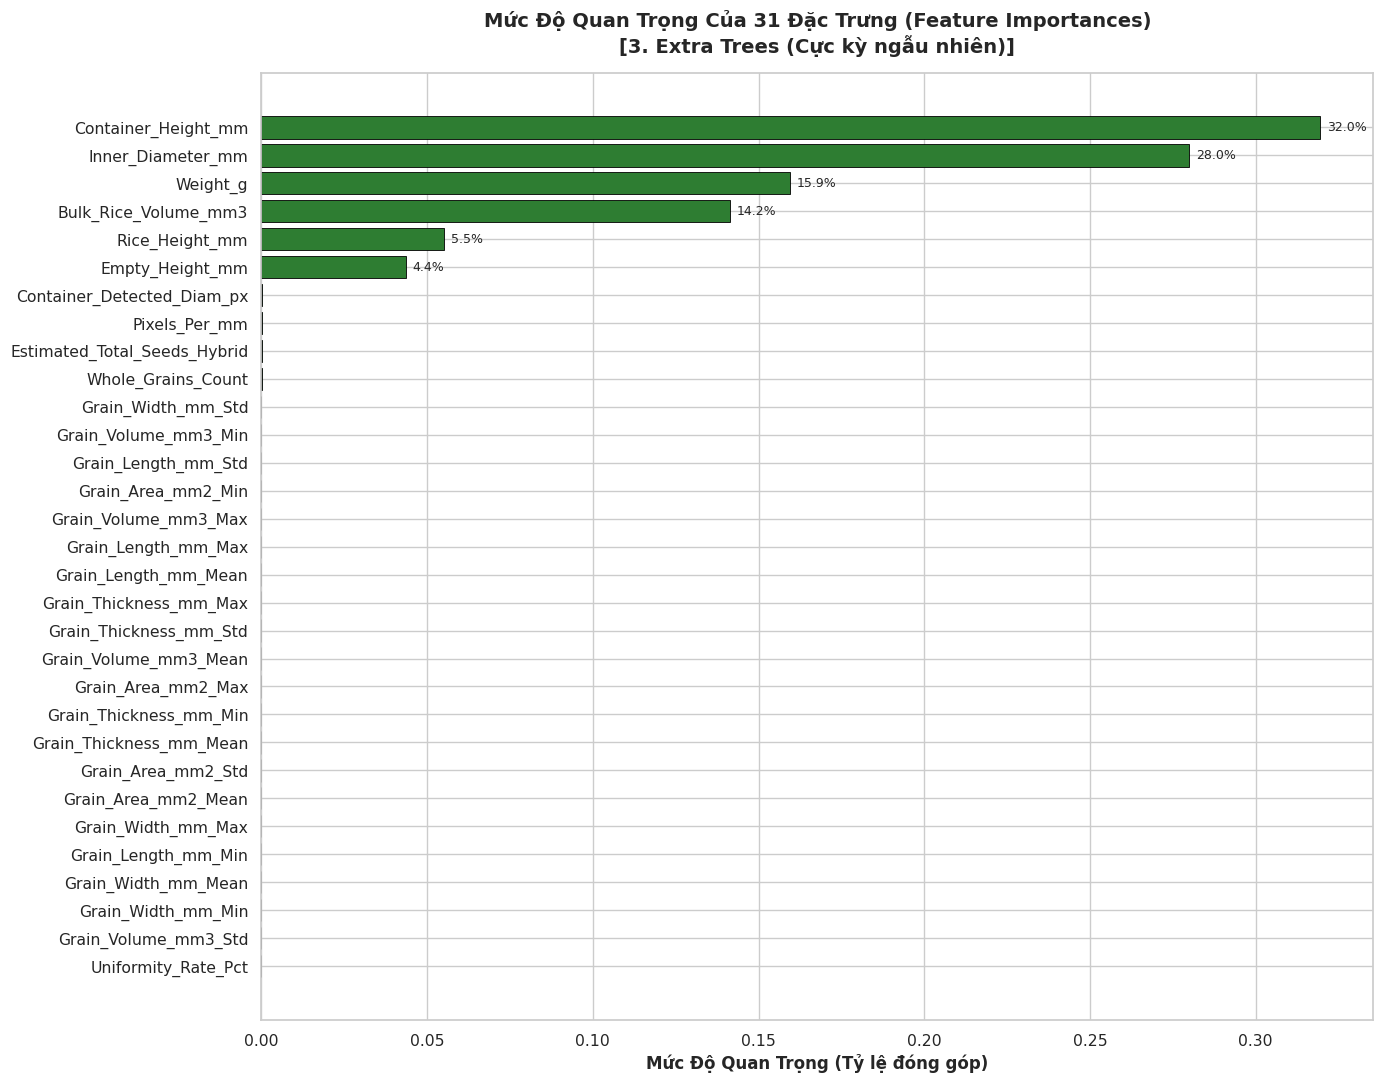

💾 Đã lưu biểu đồ Feature Importances vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/2_all_31_features_importances_chart.png


In [26]:
# Bước 7: TRỰC QUAN HÓA ĐỘ QUAN TRỌNG CỦA TOÀN BỘ 31 ĐẶC TRƯNG (FEATURE IMPORTANCES)
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Kiểm tra xem mô hình tốt nhất có hỗ trợ trích xuất độ quan trọng không
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_

    # 2. Sắp xếp các đặc trưng theo độ quan trọng giảm dần
    sorted_idx = np.argsort(importances)[::-1]
    feat_sorted = [ALL_31_FEATURES[i] for i in sorted_idx]
    imp_sorted = importances[sorted_idx]

    # 3. Vẽ biểu đồ
    plt.figure(figsize=(14, 11))

    # Dùng [::-1] để đảo ngược lại khi vẽ biểu đồ thanh ngang (biến quan trọng nhất nằm trên cùng)
    bars = plt.barh(feat_sorted[::-1], imp_sorted[::-1], color='#2E7D32', edgecolor='black', linewidth=0.6)

    # 4. Định dạng biểu đồ
    plt.title(f"Mức Độ Quan Trọng Của 31 Đặc Trưng (Feature Importances)\n[{best_model_name}]",
              fontweight='bold', fontsize=14, pad=15)
    plt.xlabel("Mức Độ Quan Trọng (Tỷ lệ đóng góp)", fontweight='bold', fontsize=12)

    # 5. Thêm nhãn % trực tiếp lên các thanh bar cho dễ quan sát
    for bar in bars:
        width = bar.get_width()
        if width > 0.001:  # Chỉ hiển thị số cho những đặc trưng có đóng góp đáng kể (> 0.1%)
            plt.text(width + 0.002, bar.get_y() + bar.get_height()/2,
                     f'{width*100:.1f}%', va='center', ha='left', fontsize=9)

    plt.tight_layout()

    # 6. Lưu và hiển thị
    importance_chart_path = os.path.join(OUTPUT_RESULT_DIR, "2_all_31_features_importances_chart.png")
    plt.savefig(importance_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Đã lưu biểu đồ Feature Importances vào: {importance_chart_path}")

else:
    print(f"⚠️ Không thể vẽ biểu đồ: Mô hình '{best_model_name}' không lưu trữ thuộc tính 'feature_importances_'.")

In [27]:
# Bước 8: XUẤT BẢNG KẾT QUẢ DỰ ĐOÁN CHI TIẾT TẬP KIỂM THỬ (TEST SET)
df_test_results = pd.DataFrame({
    'Sample_ID': sids_test,
    'Actual_Count': y_test,
    'Predicted_Count': np.round(y_te_pred, 2),
    'Error_Seeds': np.round(y_te_pred - y_test, 2),
    'Abs_Error': np.round(np.abs(y_te_pred - y_test), 2),
    'Percentage_Error_%': np.round(np.abs((y_te_pred - y_test) / y_test) * 100, 2)
}).sort_values(by='Abs_Error', ascending=False)

test_pred_csv = os.path.join(OUTPUT_RESULT_DIR, "test_set_predictions.csv")
df_test_results.to_csv(test_pred_csv, index=False, encoding="utf-8-sig")

print("=" * 95)
print(f"📋 [BẢNG 10 MẪU TEST DỰ ĐOÁN MẪU]:")
print("=" * 95)
display(df_test_results.head(10))
print(f"💾 Đã lưu toàn bộ bảng dự đoán tập Test vào: {test_pred_csv}")


📋 [BẢNG 10 MẪU TEST DỰ ĐOÁN MẪU]:


,Sample_ID,Actual_Count,Predicted_Count,Error_Seeds,Abs_Error,Percentage_Error_%
22,M025a,140,135.35,-4.65,4.65,3.32
37,M004d,125,128.55,3.55,3.55,2.84
39,M030a,170,172.45,2.45,2.45,1.44
46,M004b,125,127.10,2.10,2.10,1.68
28,M003a,115,116.40,1.40,1.40,1.22
23,M036a,200,198.80,-1.20,1.20,0.60
19,M005e,135,134.00,-1.00,1.00,0.74
4,M024c,130,129.25,-0.75,0.75,0.58
17,M004a,125,125.70,0.70,0.70,0.56
29,M039a,215,214.40,-0.60,0.60,0.28


💾 Đã lưu toàn bộ bảng dự đoán tập Test vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/LINEAR_REGRESSION_MODEL/results/test_set_predictions.csv


In [28]:
# Bước 9: THỬ NGHIỆM DỰ ĐOÁN TỨC THÌ CHO 1 MẪU MỚI (INTERACTIVE PREDICTION)
# Bạn có thể thay đổi bất kỳ giá trị nào dưới đây để kiểm tra kết quả dự đoán số hạt:
sample_test_input = {
    "Bulk_Rice_Volume_mm3": 5723.45,
    "Rice_Height_mm": 23.0,
    "Weight_g": 2.69,
    "Empty_Height_mm": 10.9,
    "Pixels_Per_mm": 37.15,
    "Container_Detected_Diam_px": 661.0,
    "Inner_Diameter_mm": 17.8,
    "Container_Height_mm": 33.9,
    "Whole_Grains_Count": 7.0,
    "Uniformity_Rate_Pct": 100.0,
    "Estimated_Total_Seeds_Hybrid": 141.0,
    "Grain_Length_mm_Mean": 5.33,
    "Grain_Length_mm_Min": 3.74,
    "Grain_Length_mm_Max": 6.87,
    "Grain_Length_mm_Std": 0.98,
    "Grain_Width_mm_Mean": 1.86,
    "Grain_Width_mm_Min": 1.56,
    "Grain_Width_mm_Max": 2.35,
    "Grain_Width_mm_Std": 0.29,
    "Grain_Thickness_mm_Mean": 4.53,
    "Grain_Thickness_mm_Min": 3.18,
    "Grain_Thickness_mm_Max": 5.84,
    "Grain_Thickness_mm_Std": 0.84,
    "Grain_Area_mm2_Mean": 7.38,
    "Grain_Area_mm2_Min": 5.38,
    "Grain_Area_mm2_Max": 11.40,
    "Grain_Area_mm2_Std": 2.29,
    "Grain_Volume_mm3_Mean": 25.19,
    "Grain_Volume_mm3_Min": 11.96,
    "Grain_Volume_mm3_Max": 49.25,
    "Grain_Volume_mm3_Std": 12.73
}

# Chuyển sample thành vector mảng
sample_vector = np.array([[sample_test_input[feat] for feat in ALL_31_FEATURES]])
sample_vector_scaled = scaler.transform(sample_vector)
predicted_count = best_model.predict(sample_vector_scaled)[0]

print("=" * 80)
print("🎯 KẾT QUẢ DỰ ĐOÁN SỐ LƯỢNG HẠT CHO MẪU:")
print("=" * 80)
print(f"🔹 Số hạt dự đoán (Predicted Count) : {int(round(predicted_count))} HẠT (Giá trị thô: {predicted_count:.2f})")
print(f"🔹 Độ tin cậy mô hình             : R² = {df_leaderboard.iloc[0]['R2_Test']} (Sai số MAE ~{df_leaderboard.iloc[0]['MAE_Test (hạt)']} hạt)")
print("=" * 80)


🎯 KẾT QUẢ DỰ ĐOÁN SỐ LƯỢNG HẠT CHO MẪU:
🔹 Số hạt dự đoán (Predicted Count) : 85 HẠT (Giá trị thô: 85.00)
🔹 Độ tin cậy mô hình             : R² = 0.9999 (Sai số MAE ~0.45 hạt)
